In [2]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Splitting & Model Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# XGBoost
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'pandas'

In [1]:
import sys
import xgboost as xgb

print("Python:", sys.executable)
print("XGBoost:", xgb.__version__)


Python: /opt/anaconda3/envs/xgb_env/bin/python
XGBoost: 3.2.0


In [3]:
conda install -c conda-forge pandas numpy scikit-learn matplotlib ipykernel -y

Channels:
 - conda-forge
 - defaults
Platform: osx-64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3/envs/xgb_env

  added / updated specs:
    - ipykernel
    - matplotlib
    - numpy
    - pandas
    - scikit-learn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    brotli-1.2.0               |       hf139dec_1          20 KB  conda-forge
    brotli-bin-1.2.0           |       h8616949_1          18 KB  conda-forge
    contourpy-1.3.3            |  py311h9d13916_4         290 KB  conda-forge
    cycler-0.12.1              |     pyhcf101f3_2          14 KB  conda-forge
    fonttools-4.61.1           |  py311he13f9b5_0         2.8 MB  conda-forge
    freetype-2.14.1            |       h694c41f_0         170 KB  conda-forge
    kiwisolver-1.4.9           |  py311h591569d_2          66 KB  conda-forge
    lcms2-2.18                 |       h90db99b_0   

 ... (more hidden) ...


python-3.11.11       | 14.8 MB   |                                       |   0% 



fonttools-4.61.1     | 2.8 MB    | 2                                     |   1% 
pandas-3.0.0         | 13.8 MB   |                                       |   0% 

matplotlib-base-3.10 | 7.8 MB    |                                       |   0% 



fonttools-4.61.1     | 2.8 MB    | ####3                                 |  12% 


tk-8.6.13            | 3.1 MB    | ###8                                  |  10% 

matplotlib-base-3.10 | 7.8 MB    | 6                                     |   2% 
python-3.11.11       | 14.8 MB   | 7                                     |   2% 

matplotlib-base-3.10 | 7.8 MB    | #                                     |   3% 
python-3.11.11       | 14.8 MB   | #1                                    |   3% 



fonttools-4.61.1     | 2.8 MB    | ######7                               |  18% 


tk-8.6.13            | 3.1 MB    | #####9                           

pandas-3.0.0         | 13.8 MB   | #########5                            |  26% 






python-3.11.11       | 14.8 MB   | ###############9                      |  43% 
pandas-3.0.0         | 13.8 MB   | ##########                            |  27% 





pillow-12.1.1        | 956 KB    | ##################################### | 100% 

matplotlib-base-3.10 | 7.8 MB    | ##################1                   |  49% 






python-3.11.11       | 14.8 MB   | ################8                     |  45% 

matplotlib-base-3.10 | 7.8 MB    | ###################5                  |  53% 



python-3.11.11       | 14.8 MB   | #################5                    |  47% 







zstd-1.5.7           | 516 KB    | #1                                    |   3% 






libjpeg-turbo-3.1.2  | 572 KB    | ###################################1  |  95% 
pandas-3.0.0         | 13.8 MB   | ##########4                           |  28% 

python-3.11.11       | 14.8 MB   | ###################4                  

libpng-1.6.55        | 292 KB    | ##                                    |   5% 

matplotlib-base-3.10 | 7.8 MB    | ################################7     |  89% 
















libpng-1.6.55        | 292 KB    | ##############1                       |  38% 

















contourpy-1.3.3      | 290 KB    | ####################4                 |  55% 














libxcb-1.17.0        | 316 KB    | ##################################### | 100% 
python-3.11.11       | 14.8 MB   | ##################################4   |  93% 
















libpng-1.6.55        | 292 KB    | ########################3             |  66% 

matplotlib-base-3.10 | 7.8 MB    | #################################5    |  91% 

















python-3.11.11       | 14.8 MB   | ###################################4  |  96% 
















libpng-1.6.55        | 292 KB    | ##################################4   |  93% 
pandas-3.0.0         | 13.8 MB   | ################2                     |  44% 

matplotlib

Preparing transaction: done
Verifying transaction: done
Executing transaction: done

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Splitting & Model Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# XGBoost
from xgboost import XGBClassifier

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Load dataset
df = pd.read_csv("term-deposit-marketing-2020.csv")

# Basic preview
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (40000, 14)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y']

First 5 Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [6]:
# Dataset information
print("Dataset Information:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  str  
 2   marital    40000 non-null  str  
 3   education  40000 non-null  str  
 4   default    40000 non-null  str  
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  str  
 7   loan       40000 non-null  str  
 8   contact    40000 non-null  str  
 9   day        40000 non-null  int64
 10  month      40000 non-null  str  
 11  duration   40000 non-null  int64
 12  campaign   40000 non-null  int64
 13  y          40000 non-null  str  
dtypes: int64(5), str(9)
memory usage: 4.3 MB

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0


In [7]:
df_model = df.copy()

# Convert Age into Age Groups
df_model["age_group"] = pd.cut(
    df_model["age"],
    bins=[0, 30, 40, 50, 60, np.inf],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

# Convert Balance into Balance Groups
df_model["balance_group"] = pd.cut(
    df_model["balance"],
    bins=[-np.inf, -1, 500, 2000, 5000, np.inf],
    labels=[
        "<0",
        "0-500",
        "501-2000",
        "2001-5000",
        "5000+"
    ]
)

# Convert Day into Week Groups
df_model["week"] = pd.cut(
    df_model["day"],
    bins=[0, 7, 14, 21, 31],
    labels=["Week 1", "Week 2", "Week 3", "Week 4"]
)

# Convert Month into Quarter
quarter_mapping = {
    "jan": "Q1", "feb": "Q1", "mar": "Q1",
    "apr": "Q2", "may": "Q2", "jun": "Q2",
    "jul": "Q3", "aug": "Q3", "sep": "Q3",
    "oct": "Q4", "nov": "Q4", "dec": "Q4"
}

df_model["quarter"] = df_model["month"].map(quarter_mapping)

# Remove original and excluded features
df_model.drop(
    columns=[
        "age",
        "balance",
        "day",
        "month",
        "contact"
    ],
    inplace=True
)

# Check final modeling columns
print("Modeling Dataset Shape:", df_model.shape)

print("\nFinal Columns:")
print(df_model.columns.tolist())

print("\nFirst 5 Rows:")
display(df_model.head())

Modeling Dataset Shape: (40000, 13)

Final Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'duration', 'campaign', 'y', 'age_group', 'balance_group', 'week', 'quarter']

First 5 Rows:


,job,marital,education,default,housing,loan,duration,campaign,y,age_group,balance_group,week,quarter
0,management,married,tertiary,no,yes,no,261,1,no,51-60,2001-5000,Week 1,Q2
1,technician,single,secondary,no,yes,no,151,1,no,41-50,0-500,Week 1,Q2
2,entrepreneur,married,secondary,no,yes,yes,76,1,no,31-40,0-500,Week 1,Q2
3,blue-collar,married,unknown,no,yes,no,92,1,no,41-50,501-2000,Week 1,Q2
4,unknown,single,unknown,no,no,no,198,1,no,31-40,0-500,Week 1,Q2


In [8]:
from sklearn.model_selection import train_test_split

# Features
X = df_model.drop(columns=["y"])

# Target: no = 0, yes = 1
y = df_model["y"].map({
    "no": 0,
    "yes": 1
})

# 70% Training / 30% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Target Distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train Shape: (28000, 12)
X_test Shape : (12000, 12)

Training Target Distribution:
y
0    25973
1     2027
Name: count, dtype: int64
y
0    92.76
1     7.24
Name: proportion, dtype: float64

Testing Target Distribution:
y
0    11131
1      869
Name: count, dtype: int64
y
0    92.76
1     7.24
Name: proportion, dtype: float64


In [9]:
print("Training Features:")
print(X_train.dtypes)

print("\nTotal Features:", X_train.shape[1])

Training Features:
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
duration            int64
campaign            int64
age_group        category
balance_group    category
week             category
quarter               str
dtype: object

Total Features: 12


In [10]:
categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "age_group",
    "balance_group",
    "week",
    "quarter"
]

numerical_features = [
    "duration",
    "campaign"
]

preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

X_train_processed = preprocessor_xgb.fit_transform(X_train)
X_test_processed = preprocessor_xgb.transform(X_test)

print("Before Preprocessing:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nAfter Preprocessing:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)

Before Preprocessing:
X_train: (28000, 12)
X_test : (12000, 12)

After Preprocessing:
X_train_processed: (28000, 45)
X_test_processed : (12000, 45)


## Baseline XGBoost Model

In [11]:
xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_baseline.fit(
    X_train_processed,
    y_train
)

y_pred_xgb = xgb_baseline.predict(X_test_processed)

y_prob_xgb = xgb_baseline.predict_proba(
    X_test_processed
)[:, 1]

In [12]:
baseline_accuracy = accuracy_score(y_test, y_pred_xgb)
baseline_precision = precision_score(y_test, y_pred_xgb)
baseline_recall = recall_score(y_test, y_pred_xgb)
baseline_f1 = f1_score(y_test, y_pred_xgb)
baseline_auc = roc_auc_score(y_test, y_prob_xgb)

print("Baseline XGBoost Performance")
print("-" * 35)

print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")
print(f"ROC-AUC  : {baseline_auc:.4f}")

Baseline XGBoost Performance
-----------------------------------
Accuracy : 0.9322
Precision: 0.5558
Recall   : 0.3153
F1 Score : 0.4023
ROC-AUC  : 0.9177


In [13]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.96     11131
           1       0.56      0.32      0.40       869

    accuracy                           0.93     12000
   macro avg       0.75      0.65      0.68     12000
weighted avg       0.92      0.93      0.92     12000



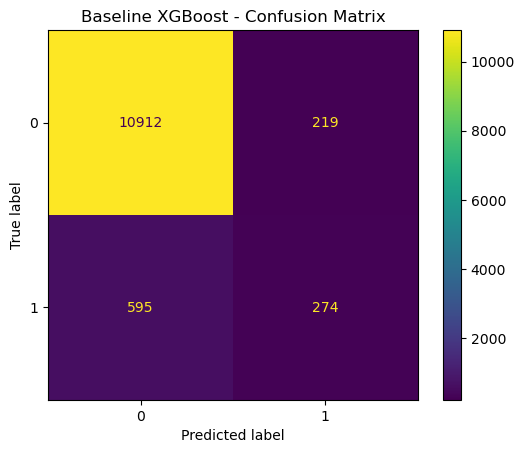

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb
)

plt.title("Baseline XGBoost - Confusion Matrix")
plt.show()

## Handle Class Imbalance Using scale_pos_weight

In [17]:
from sklearn.model_selection import cross_validate

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

imbalance_ratio = negative_count / positive_count

print("Negative Samples:", negative_count)
print("Positive Samples:", positive_count)
print(f"Calculated scale_pos_weight: {imbalance_ratio:.2f}")

Negative Samples: 25973
Positive Samples: 2027
Calculated scale_pos_weight: 12.81


## XGBoost GridSearch 1

In [19]:
xgb_grid_1 = {
    "n_estimators": [100, 150, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Calculate total parameter combinations
total_combinations_1 = np.prod(
    [len(values) for values in xgb_grid_1.values()]
)

print("XGBoost GridSearch 1")
print("-" * 30)
print("Parameter Combinations:", total_combinations_1)
print("5-Fold CV Total Fits:", total_combinations_1 * 5)

print("\nParameters:")
for parameter, values in xgb_grid_1.items():
    print(f"{parameter}: {values}")

XGBoost GridSearch 1
------------------------------
Parameter Combinations: 216
5-Fold CV Total Fits: 1080

Parameters:
n_estimators: [100, 150, 200]
max_depth: [3, 5, 7]
learning_rate: [0.03, 0.05, 0.1]
min_child_weight: [1, 3]
subsample: [0.8, 1.0]
colsample_bytree: [0.8, 1.0]


In [20]:
# XGBoost GridSearch 1

xgb_model_1 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
)

xgb_grid_search_1 = GridSearchCV(
    estimator=xgb_model_1,
    param_grid=xgb_grid_1,
    scoring="f1",
    cv=5,
    n_jobs=1,
    verbose=2
)

xgb_grid_search_1.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; tot

[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.0

[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=7, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=7, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=7, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=7, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=7, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=7, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=7, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.0

[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.0

[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.0

...

[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=150, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=150, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.0

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=150, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_d

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_d

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=150, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_d

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [21]:
# XGBoost GridSearch 1 - Best Results

print("XGBoost GridSearch 1 - Best Results")
print("-" * 40)

print("\nBest Parameters:")
print(xgb_grid_search_1.best_params_)

print("\nBest CV F1 Score:")
print(round(xgb_grid_search_1.best_score_, 4))

XGBoost GridSearch 1 - Best Results
----------------------------------------

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 1.0}

Best CV F1 Score:
0.4028


In [22]:
# XGBoost GridSearch 1 - Test Set Evaluation

xgb_best_1 = xgb_grid_search_1.best_estimator_

y_pred_xgb_grid_1 = xgb_best_1.predict(X_test_processed)
y_prob_xgb_grid_1 = xgb_best_1.predict_proba(X_test_processed)[:, 1]

xgb_grid_1_accuracy = accuracy_score(y_test, y_pred_xgb_grid_1)
xgb_grid_1_precision = precision_score(y_test, y_pred_xgb_grid_1)
xgb_grid_1_recall = recall_score(y_test, y_pred_xgb_grid_1)
xgb_grid_1_f1 = f1_score(y_test, y_pred_xgb_grid_1)
xgb_grid_1_auc = roc_auc_score(y_test, y_prob_xgb_grid_1)

print("XGBoost GridSearch 1 - Test Performance")
print("-" * 45)

print(f"Accuracy : {xgb_grid_1_accuracy:.4f}")
print(f"Precision: {xgb_grid_1_precision:.4f}")
print(f"Recall   : {xgb_grid_1_recall:.4f}")
print(f"F1 Score : {xgb_grid_1_f1:.4f}")
print(f"ROC-AUC  : {xgb_grid_1_auc:.4f}")

XGBoost GridSearch 1 - Test Performance
---------------------------------------------
Accuracy : 0.9322
Precision: 0.5607
Recall   : 0.2923
F1 Score : 0.3843
ROC-AUC  : 0.9254


## # XGBoost GridSearch 2

In [23]:
# Parameter Grid
xgb_grid_2 = {
    "n_estimators": [200, 250, 300],
    "max_depth": [4, 5, 6],
    "learning_rate": [0.08, 0.10, 0.12],
    "min_child_weight": [2, 3, 4],
    "subsample": [0.9, 1.0],
    "colsample_bytree": [0.9, 1.0]
}

# XGBoost Model
xgb_model_2 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
)

# GridSearchCV
xgb_grid_search_2 = GridSearchCV(
    estimator=xgb_model_2,
    param_grid=xgb_grid_2,
    scoring="f1",
    cv=5,
    n_jobs=1,
    verbose=0
)

# Fit GridSearch
xgb_grid_search_2.fit(
    X_train_processed,
    y_train
)

# Best Model
xgb_best_2 = xgb_grid_search_2.best_estimator_

# Best Results
print("XGBoost GridSearch 2 - Best Results")
print("-" * 40)

print("\nBest Parameters:")
print(xgb_grid_search_2.best_params_)

print("\nBest CV F1 Score:")
print(round(xgb_grid_search_2.best_score_, 4))

XGBoost GridSearch 2 - Best Results
----------------------------------------

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.12, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 1.0}

Best CV F1 Score:
0.411


In [24]:
# XGBoost GridSearch 2 - Test Set Evaluation

y_pred_xgb_grid_2 = xgb_best_2.predict(X_test_processed)
y_prob_xgb_grid_2 = xgb_best_2.predict_proba(X_test_processed)[:, 1]

xgb_grid_2_accuracy = accuracy_score(y_test, y_pred_xgb_grid_2)
xgb_grid_2_precision = precision_score(y_test, y_pred_xgb_grid_2)
xgb_grid_2_recall = recall_score(y_test, y_pred_xgb_grid_2)
xgb_grid_2_f1 = f1_score(y_test, y_pred_xgb_grid_2)
xgb_grid_2_auc = roc_auc_score(y_test, y_prob_xgb_grid_2)

print("XGBoost GridSearch 2 - Test Performance")
print("-" * 45)

print(f"Accuracy : {xgb_grid_2_accuracy:.4f}")
print(f"Precision: {xgb_grid_2_precision:.4f}")
print(f"Recall   : {xgb_grid_2_recall:.4f}")
print(f"F1 Score : {xgb_grid_2_f1:.4f}")
print(f"ROC-AUC  : {xgb_grid_2_auc:.4f}")

XGBoost GridSearch 2 - Test Performance
---------------------------------------------
Accuracy : 0.9339
Precision: 0.5809
Recall   : 0.3142
F1 Score : 0.4078
ROC-AUC  : 0.9253


##  XGBoost GridSearch 3

In [25]:
# Parameter Grid
xgb_grid_3 = {
    "n_estimators": [150, 200, 250],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.10, 0.12, 0.15],
    "min_child_weight": [2, 3, 5],
    "subsample": [0.9, 1.0],
    "colsample_bytree": [0.9, 1.0]
}

# XGBoost Model
xgb_model_3 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
)

# GridSearchCV
xgb_grid_search_3 = GridSearchCV(
    estimator=xgb_model_3,
    param_grid=xgb_grid_3,
    scoring="f1",
    cv=5,
    n_jobs=1,
    verbose=0
)

# Fit GridSearch
xgb_grid_search_3.fit(
    X_train_processed,
    y_train
)

# Best Model
xgb_best_3 = xgb_grid_search_3.best_estimator_

# Best Results
print("XGBoost GridSearch 3 - Best Results")
print("-" * 40)

print("\nBest Parameters:")
print(xgb_grid_search_3.best_params_)

print("\nBest CV F1 Score:")
print(round(xgb_grid_search_3.best_score_, 4))

XGBoost GridSearch 3 - Best Results
----------------------------------------

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.15, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 1.0}

Best CV F1 Score:
0.4115


In [26]:
# XGBoost GridSearch 3 - Test Set Evaluation

y_pred_xgb_grid_3 = xgb_best_3.predict(X_test_processed)
y_prob_xgb_grid_3 = xgb_best_3.predict_proba(X_test_processed)[:, 1]

xgb_grid_3_accuracy = accuracy_score(y_test, y_pred_xgb_grid_3)
xgb_grid_3_precision = precision_score(y_test, y_pred_xgb_grid_3)
xgb_grid_3_recall = recall_score(y_test, y_pred_xgb_grid_3)
xgb_grid_3_f1 = f1_score(y_test, y_pred_xgb_grid_3)
xgb_grid_3_auc = roc_auc_score(y_test, y_prob_xgb_grid_3)

print("XGBoost GridSearch 3 - Test Performance")
print("-" * 45)

print(f"Accuracy : {xgb_grid_3_accuracy:.4f}")
print(f"Precision: {xgb_grid_3_precision:.4f}")
print(f"Recall   : {xgb_grid_3_recall:.4f}")
print(f"F1 Score : {xgb_grid_3_f1:.4f}")
print(f"ROC-AUC  : {xgb_grid_3_auc:.4f}")

XGBoost GridSearch 3 - Test Performance
---------------------------------------------
Accuracy : 0.9334
Precision: 0.5742
Recall   : 0.3119
F1 Score : 0.4042
ROC-AUC  : 0.9245


## XGBoost GridSearch 4

In [28]:
# XGBoost GridSearch 4 - Class Imbalance Tuning

xgb_grid_4 = {
    "n_estimators": [150, 200, 250],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.10, 0.12, 0.15],
    "min_child_weight": [2, 3, 4],
    "scale_pos_weight": [1, 1.5, 2, 3]
}

xgb_model_4 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=1
)

xgb_grid_search_4 = GridSearchCV(
    estimator=xgb_model_4,
    param_grid=xgb_grid_4,
    scoring="f1",
    cv=5,
    n_jobs=1,
    verbose=0
)

xgb_grid_search_4.fit(
    X_train_processed,
    y_train
)

xgb_best_4 = xgb_grid_search_4.best_estimator_

print("XGBoost GridSearch 4 - Best Results")
print("-" * 40)

print("\nBest Parameters:")
print(xgb_grid_search_4.best_params_)

print("\nBest CV F1 Score:")
print(round(xgb_grid_search_4.best_score_, 4))

XGBoost GridSearch 4 - Best Results
----------------------------------------

Best Parameters:
{'learning_rate': 0.12, 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 250, 'scale_pos_weight': 3}

Best CV F1 Score:
0.5305


In [29]:
# XGBoost GridSearch 4 - Test Set Evaluation

y_pred_xgb_grid_4 = xgb_best_4.predict(X_test_processed)
y_prob_xgb_grid_4 = xgb_best_4.predict_proba(X_test_processed)[:, 1]

xgb_grid_4_accuracy = accuracy_score(y_test, y_pred_xgb_grid_4)
xgb_grid_4_precision = precision_score(y_test, y_pred_xgb_grid_4)
xgb_grid_4_recall = recall_score(y_test, y_pred_xgb_grid_4)
xgb_grid_4_f1 = f1_score(y_test, y_pred_xgb_grid_4)
xgb_grid_4_auc = roc_auc_score(y_test, y_prob_xgb_grid_4)

print("XGBoost GridSearch 4 - Test Performance")
print("-" * 45)

print(f"Accuracy : {xgb_grid_4_accuracy:.4f}")
print(f"Precision: {xgb_grid_4_precision:.4f}")
print(f"Recall   : {xgb_grid_4_recall:.4f}")
print(f"F1 Score : {xgb_grid_4_f1:.4f}")
print(f"ROC-AUC  : {xgb_grid_4_auc:.4f}")

XGBoost GridSearch 4 - Test Performance
---------------------------------------------
Accuracy : 0.9195
Precision: 0.4591
Recall   : 0.6260
F1 Score : 0.5297
ROC-AUC  : 0.9256


In [32]:
# XGBoost GridSearch 4 - Feature Importance

feature_names = preprocessor_xgb.get_feature_names_out()

feature_importance_xgb_4 = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_best_4.feature_importances_
})

feature_importance_xgb_4 = feature_importance_xgb_4.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 Important Features - XGBoost GridSearch 4")
print("-" * 55)

display(feature_importance_xgb_4.head(20).round(4))

Top 20 Important Features - XGBoost GridSearch 4
-------------------------------------------------------


,Feature,Importance
0,num__duration,0.1332
1,cat__week_Week 3,0.0898
2,cat__age_group_60+,0.0682
3,cat__quarter_Q3,0.0671
4,cat__housing_no,0.0650
5,cat__quarter_Q1,0.0560
6,cat__quarter_Q4,0.0460
7,cat__age_group_18-30,0.0380
8,cat__week_Week 4,0.0361
9,cat__week_Week 2,0.0313


In [3]:
# Confusion Matrix - Final XGBoost Model

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No", "Yes"]
)

disp.plot(values_format="d")

plt.title("Confusion Matrix - XGBoost GridSearch 4")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

NameError: name 'ConfusionMatrixDisplay' is not defined

In [38]:
import optuna

print("Optuna Version:", optuna.__version__)

Optuna Version: 5.0.0


/opt/anaconda3/envs/xgb_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Optuna Objective Function for XGBoost

In [41]:
from sklearn.model_selection import cross_val_score

In [1]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 800
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.30, log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 2, 8
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),

        "gamma": trial.suggest_float(
            "gamma", 0.0, 5.0
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 0.0, 10.0
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 0.0, 10.0
        ),

        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight", 1.0, 6.0
        )
    }

    model = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_processed,
        y_train,
        scoring="f1",
        cv=cv,
        n_jobs=1
    )

    return scores.mean()

## Run Optuna Study

In [43]:
# Run Optuna Optimization

optuna.logging.set_verbosity(optuna.logging.WARNING)

xgb_optuna_study = optuna.create_study(
    direction="maximize",
    study_name="XGBoost_Optuna_F1"
)

xgb_optuna_study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

print("Optuna Optimization Completed")
print("-" * 40)

print("\nBest CV F1 Score:")
print(round(xgb_optuna_study.best_value, 4))

print("\nBest Parameters:")
print(xgb_optuna_study.best_params)

Best trial: 96. Best value: 0.531507: 100%|██| 100/100 [17:24<00:00, 10.45s/it]

Optuna Optimization Completed
----------------------------------------

Best CV F1 Score:
0.5315

Best Parameters:
{'n_estimators': 688, 'learning_rate': 0.08113507128867012, 'max_depth': 8, 'min_child_weight': 5, 'gamma': 2.3876244814411316, 'subsample': 0.8415121949170846, 'colsample_bytree': 0.6590845855490501, 'reg_alpha': 7.94955310425837, 'reg_lambda': 4.2330608784537915, 'scale_pos_weight': 3.2014242652863425}


In [2]:
# Optuna Study 1 - Best Model and Test Evaluation

xgb_optuna_best_1 = XGBClassifier(
    **xgb_optuna_study_1.best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
)

# Train Best Model
xgb_optuna_best_1.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_xgb_optuna_1 = xgb_optuna_best_1.predict(
    X_test_processed
)

y_prob_xgb_optuna_1 = xgb_optuna_best_1.predict_proba(
    X_test_processed
)[:, 1]

# Evaluation Metrics
xgb_optuna_1_accuracy = accuracy_score(
    y_test, y_pred_xgb_optuna_1
)

xgb_optuna_1_precision = precision_score(
    y_test, y_pred_xgb_optuna_1
)

xgb_optuna_1_recall = recall_score(
    y_test, y_pred_xgb_optuna_1
)

xgb_optuna_1_f1 = f1_score(
    y_test, y_pred_xgb_optuna_1
)

xgb_optuna_1_auc = roc_auc_score(
    y_test, y_prob_xgb_optuna_1
)

print("XGBoost Optuna Study 1 - Test Performance")
print("-" * 45)

print(f"Accuracy : {xgb_optuna_1_accuracy:.4f}")
print(f"Precision: {xgb_optuna_1_precision:.4f}")
print(f"Recall   : {xgb_optuna_1_recall:.4f}")
print(f"F1 Score : {xgb_optuna_1_f1:.4f}")
print(f"ROC-AUC  : {xgb_optuna_1_auc:.4f}")

NameError: name 'XGBClassifier' is not defined